# Key metrics

Sources:
- Municipal Fiscal indicators: https://data.ct.gov/browse?tags=2023+municipal+fiscal+indicators&sortBy=relevance&pageSize=20
- Equalized net grand list: https://portal.ct.gov/OPM/IGPP/IGPP-Home
- Municipal expenses by function https://data.ct.gov/Local-Government/Municipal-Fiscal-Indicators-Uniform-Chart-of-Accou/3gbm-qe5e/about_data
- Municipal Spending data: https://catalog.data.gov/dataset/uniform-chart-of-accounts-municipal-spending-data
- IRS tax return information by ZIP: https://www.irs.gov/statistics/soi-tax-stats-individual-income-tax-statistics-zip-code-data-soi
- OASDI (Social Security) by ZIP and year: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html

In [1]:
import os.path as path
import re
from datetime import datetime
import numpy as np
from scipy import stats
import polars as pl
import pandas as pd
pd.options.display.html.use_mathjax = False

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Set the rcParam "text.usetex" to False
plt.rcParams["text.usetex"] = False

## Functions

In [2]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

In [3]:
# for plotting
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"

png_metadata = {
'Title': "Social Security Income",
'Author': 'Joel Danke',
'Description': "Based on OASDI data https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html",
'Creation Time': rundate,
'Software': software}

## Town to Regional Schools
```
Regional School District 1| (serving 9-12 in Canaan, Cornwall, Kent, North Canaan, Salisbury and Sharon)
Regional School District 4| (serving 7-12 in Chester, Deep River and Essex)
Regional School District 5| (serving 7-12 in Bethany, Orange and Woodbridge)
Regional School District 6| (serving Goshen, Morris and Warren) <-----------
Regional School District 7| (serving 7-12 in Barkhamsted, Colebrook, New Hartford and Norfolk)
Regional School District 8| (serving 7-12 in Andover, Hebron and Marlborough)
Regional School District 9| (serving 9-12 in Easton and Redding)
Regional School District 10| (serving Burlington and Harwinton)
Regional School District 11| (serving 9-12 in Chaplin, Hampton and Scotland)
Regional School District 12| (serving Bridgewater, Roxbury and Washington) <-------------
Regional School District 13| (serving Durham and Middlefield) <--------------
Regional School District 14| (serving Bethlehem and Woodbury)
Regional School District 15| (serving Middlebury and Southbury) <------------
Regional School District 16| (serving Beacon Falls and Prospect) <-------------
Regional School District 17| (serving Haddam and Killingworth) <-------------
Regional School District 18| (serving Lyme and Old Lyme) <-------------
Regional School District 19| (serving 9-12 in Ashford, Mansfield and Willington)
```

In [4]:
regional_map = {
    'Canaan': 'Regional High School District 01',
    'Cornwall': 'Regional High School District 01',
    'Kent': 'Regional High School District 01',
    'North Canaan': 'Regional High School District 01',
    'Salisbury': 'Regional High School District 01',
    'Sharon': 'Regional High School District 01',
    'Chester': 'Regional High School District 04',
    'Deep River': 'Regional High School District 04',
    'Bethany': 'Regional High School District 04',
    'Orange': 'Regional High School District 05',
    'Woodbridge': 'Regional High School District 05',
    'Essex': 'Regional High School District 05',
    'Goshen': 'Regional School District 06',
    'Morris': 'Regional School District 06',
    'Warren': 'Regional School District 06',
    'Barkhamsted': 'Regional High School District 07',
    'Colebrook': 'Regional High School District 07',
    'New Hartford': 'Regional High School District 07',
    'Norfolk': 'Regional High School District 07',
    'Andover': 'Regional High School District 08',
    'Hebron': 'Regional High School District 08',
    'Marlborough': 'Regional High School District 08',
    'Easton': 'Regional High School District 09',
    'Redding': 'Regional High School District 09',
    'Burlington': 'Regional School District 10',
    'Harwinton': 'Regional School District 10',
    'Chaplin': 'Regional High School District 11',
    'Hampton': 'Regional High School District 11',
    'Scotland': 'Regional High School District 11',
    'Bridgewater': 'Regional School District 12',
    'Roxbury': 'Regional School District 12',
    'Washington': 'Regional School District 12',
    'Durham': 'Regional School District 13',
    'Middlefield': 'Regional School District 13',
    'Bethlehem': 'Regional School District 14',
    'Woodbury': 'Regional School District 14',
    'Middlebury': 'Regional School District 15',
    'Southbury': 'Regional School District 15',
    'Beacon Falls': 'Regional School District 16',
    'Prospect': 'Regional School District 16',
    'Haddam': 'Regional School District 17',
    'Killingworth': 'Regional School District 17',
    'Lyme': 'Regional School District 18',
    'Old Lyme': 'Regional School District 18',
    'Ashford': 'Regional High School District 19',
    'Mansfield': 'Regional High School District 19',
    'Willington': 'Regional High School District 19',
}

## Import data
### File locations

In [5]:
# incomes & fed taxes from IRS
income_dir = '/Users/joel/Desktop/Granby Benchmarking/incomes'
irs_file = path.join(income_dir, 'ct2011-2022_simplified.xlsx')

# ct state tax
# 2021-2023 filing year
cttax_recent = path.join(income_dir, 'CT_Personal_Income_Tax_by_Municipality_20250603.csv')
cttax = path.join(income_dir, 'Personal_Income_Tax_By_Town__2011-2020_20250603.csv')

# property values
# equalized has longer history plus detail by type of property
# note: grand list year + 2 = fiscal year end
# checked - this is most recent file

benchmark_dir = '/Users/joel/Desktop/Granby Benchmarking/'
eqgl_file = path.join(benchmark_dir, 'fiscal_indicators', 'Equalized_Net_Grand_List_by_Town__2011-2023_GL_.csv')

# shorter time period than above but is more recent
# also has median home values, median incomes
# updated march 2026
grandlist_file = path.join(benchmark_dir, 'fiscal_indicators', 'Municipal_Fiscal_Indicators__Economic_and_Grand_List_Data_2019-2025_20260326.csv')

# tax levy, aggregate town budget info
# also has equalized grand list data
# updated march 2026
fiscal_file = path.join(benchmark_dir, 'fiscal_indicators', 'Municipal_Fiscal_Indicators__Individual_Town_Data_2014-2023_20260326.csv')

### CT taxes

In [6]:
cttaxes =  pd.concat([pd.read_csv(cttax_recent)\
                     .rename(columns={'Filing Period': 'Year', 'Municipality': 'Town'}),
                     pd.read_csv(cttax).rename(columns={'Tax Year':'Year', 'Municipality': 'Town'})]
                  )[['Year', 'Town', 'CT Income Tax']].sort_values(by=['Year', 'Town']).drop_duplicates(subset=['Year', 'Town'])

cttaxes['Town'] = cttaxes['Town'].str.title()
cttaxes.head()

,Year,Town,CT Income Tax
676,2011,Andover,4606400.0
677,2011,Ansonia,12859369.0
678,2011,Ashford,4921563.0
679,2011,Avon,72302384.0
680,2011,Barkhamsted,7035596.0


### Inflation indices
Using year-end. Halfway through fiscal year, end of income year. Good enough

In [7]:
ipd = pd.read_csv('/Users/joel/Desktop/Granby Benchmarking/price_index_ipd_clean.csv')
ipd = ipd[ipd['Quarter'] == 'Q4'].drop(columns=['Quarter'])
ipd.columns = [c.strip() for c in ipd.columns]
ipd['IPD'] = ipd['IPD']/100

# July-Aug 2017 is 100
pce = pd.read_csv('/Users/joel/Desktop/Granby Benchmarking/price_index_pce_clean.csv')[['Year', 'Month', 'PCE']]
pce = pce[pce['Month'] == 'DEC'].drop(columns=['Month'])
pce.columns = [c.strip() for c in pce.columns]
pce['PCE'] = pce['PCE']/100

In [8]:
pce.query('Year > 2013')

,Year,PCE
179,2014,0.97120
191,2015,0.97456
203,2016,0.99071
215,2017,1.00821
227,2018,1.02701
239,2019,1.04307
251,2020,1.05699
263,2021,1.12191
275,2022,1.18384
287,2023,1.21660


In [9]:
ipd.query('Year > 2013')

,Year,IPD
59,2014,0.98073
63,2015,0.97465
67,2016,0.98195
71,2017,1.01445
75,2018,1.05190
79,2019,1.06501
83,2020,1.09926
87,2021,1.19270
91,2022,1.27180
95,2023,1.28542


### Town roads
Intent is to use for highway department benchmarking. Not critical.

In [10]:
town_roads = pd.read_csv(path.join(benchmark_dir, 'socioeconomic_factors', 'town_mileage.tab'), sep="|")\
               .rename(columns={'town': 'Town', 'sq_miles': 'Town Area', 'state_miles': 'State Roads', 'town_miles': 'Town Roads'})\
               [['Town', 'Town Area', 'State Roads', 'Town Roads']]
town_roads['Town'] = town_roads['Town'].str.title()
town_roads.head()

,Town,Town Area,State Roads,Town Roads
0,Andover,15.7,10.88,33.52
1,Ansonia,6.2,8.79,60.31
2,Ashford,39.5,20.17,67.59
3,Avon,23.5,15.86,111.65
4,Barkhamsted,38.8,27.26,47.89


In [11]:
# Expenditures by function - "uniform chart of accounts"
# https://data.ct.gov/Local-Government/Municipal-Fiscal-Indicators-Uniform-Chart-of-Accou/3gbm-qe5e/about_data
# https://catalog.data.gov/dataset/uniform-chart-of-accounts-municipal-spending-data

### ZIP codes
For converting IRS and OASDI zip code-level data to town-level. Surprisingly hard to find quality data. Borders are not perfect but we don't need to be.

In [12]:
# zip code crosswalk
# https://www.ctdata.org/geographic-resources
# hard: zips/towns not aligned
zips = pd.read_csv(path.join(benchmark_dir, '2010zip-to-town.csv'))
zips.columns = [c.capitalize() for c in zips.columns]
zips = zips.rename(columns={'2010zip5': 'ZIP code'})
zips['ZIP']= zips['ZIP code'].apply(lambda x: f"{x:05}")
zips.head()

,ZIP code,Town,County,Town_fips,ZIP
0,6810,Danbury,Fairfield,900118500,06810
1,6608,Bridgeport,Fairfield,900108070,06608
2,6468,Monroe,Fairfield,900148620,06468
3,6089,Simsbury,Hartford,900368940,06089
4,6820,Darien,Fairfield,900118850,06820


In [13]:
# zip code crosswalk
# https://www.ctdata.org/geographic-resources
# hard: zips/towns not aligned

# cleanup function:
# to avoid 'windsor', 'east windsor' type problems
# use list of town names from longest to shortest
towns = list(zips.Town.unique())
_tl = [-len(t) for t in towns]
_l, towns = zip(*sorted(zip(_tl, towns)))

def rewrite_zips():
    with open(path.join(benchmark_dir, 'post_offices.txt'), 'w') as po:
        po.write("ZIP code\tTown\tPost Office\n")
        with open(path.join(benchmark_dir, 'zip'), 'r') as f:
            lines = f.readlines()
            for line in lines:
                location, zipcode = line.split(',')
                found = False
                for _town in towns:
                    if location.endswith(_town):
                        found = True
                        town = _town
                        break
                if not found:
                    if location.endswith('Killilngly'):
                        town = 'Killingly'
                        location = location.removesuffix('Killilngly')
                    elif location.endswith('Ansoina'):
                        town  = 'Ansonia'
                        location = location.removesuffix('Ansoina')
                    elif location.endswith('Lisbon'):
                        town  = 'Lisbon'
                        location = location.removesuffix('Lisbon')
                    elif location.endswith('Union'):
                        town  = 'Union'
                        location = location.removesuffix('Union')
                        
                post_office = location.removesuffix(town)
                po.write(zipcode.strip("\n") + "\t" + town + "\t" + post_office + "\n")

In [14]:
# Gathered from https://portal.ct.gov/SOTS/Register-Manual/Section-VII/Post-Offices-in-Connecticut
post_offices = pd.read_table(path.join(benchmark_dir, 'socioeconomic_factors', 'post_offices.txt'))
post_offices.head()

,ZIP code,Town,Post Office
0,6231,Hebron,Amston
1,6331,Canterbury,Canterbury
2,6232,Andover,Andover
3,6019,Canton,Canton
4,6401,Ansonia,Ansonia


In [15]:
# unique zips, but multiple towns (POs in different zips?)
post_offices.shape, post_offices['ZIP code'].unique().shape, post_offices.drop_duplicates(subset=['ZIP code', 'Town']).shape[0]

((650, 3), (433,), 512)

In [16]:
# get zip codes for one town only (unique zip-town combos, then where only one town)
ntowns = pd.DataFrame(post_offices.drop_duplicates(subset=['ZIP code', 'Town']).groupby('ZIP code')['Town'].count())
ntowns.reset_index(drop=False, inplace=True)

# infill with secondary data source
po_towns = post_offices.merge(ntowns[ntowns['Town'] == 1].drop(columns='Town'), on='ZIP code', how='inner')
po_towns = po_towns.drop(columns=['Post Office']).drop_duplicates()
po_towns.shape, po_towns['ZIP code'].unique().shape

((362, 2), (362,))

In [17]:
po_towns.head()

,ZIP code,Town
0,6231,Hebron
1,6331,Canterbury
2,6232,Andover
3,6019,Canton
4,6401,Ansonia


### Peer Groups
For comparing Granby to similar towns.

In [18]:
# school group mapping
school_types = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/school_types.parquet')
school_types.head()

,Code,District,Low Grade,High Grade,Organization Type,DRG,peer,augmented,aspirational,peerplus,...,Home Values,% w/Bachelors+,% Management,% Single Parent,% Non-English,% SNAP,School Enrollment,% HH w/Children,% w/Broadband,% Age 65+
0,1,Andover School District,PreK,6,Public School Districts,C,1.0,0.0,0.0,1.0,...,366700.0,49.0,50.3,5.212953,5.1,3.9,694.0,24.8,96.5,36.8
1,2,Ansonia School District,PreK,12,Public School Districts,H,0.0,0.0,0.0,0.0,...,257100.0,21.1,31.2,9.438122,27.4,16.2,3970.0,26.8,84.0,33.0
2,3,Ashford School District,PreK,8,Public School Districts,E,0.0,0.0,0.0,0.0,...,301400.0,35.0,44.9,7.313843,6.6,9.0,1045.0,39.9,94.5,23.5
3,4,Avon School District,PreK,12,Public School Districts,B,0.0,1.0,1.0,0.0,...,434000.0,70.5,72.0,3.300000,20.8,2.3,4839.0,32.8,91.8,35.4
4,5,Barkhamsted School District,PreK,6,Public School Districts,C,1.0,0.0,0.0,1.0,...,325100.0,49.8,52.8,5.705772,6.9,2.1,839.0,32.3,92.0,41.3


In [19]:
school_types.columns

Index(['Code', 'District', 'Low Grade', 'High Grade', 'Organization Type',
       'DRG', 'peer', 'augmented', 'aspirational', 'peerplus', 'elite',
       'urban', 'pca', 'affordable', 'finproj', 'finprojB', 'finprojE',
       'JSG_ORIG', 'JSG_AUG', 'JSG_AFF', 'JSG_PCA10', 'Median Income',
       '% Owner Occ', 'Home Values', '% w/Bachelors+', '% Management',
       '% Single Parent', '% Non-English', '% SNAP', 'School Enrollment',
       '% HH w/Children', '% w/Broadband', '% Age 65+'],
      dtype='object')

### Fiscal Indicators
#### By Town
Covers fiscal years 2013-2014 through  2022-2023

In [20]:
fiscal_indicators = pd.read_csv(fiscal_file, thousands=',')

# year is the beginning of fiscal year, eg 2024 for 2024-25
fiscal_indicators['Year'] = fiscal_indicators['Fiscal Year End'] - 1
fiscal_indicators['Town'] = fiscal_indicators['Town'].str.title()
fiscal_indicators['Size of adjusted gross income'] = "Total"

In [21]:
fiscal_indicators['Fiscal Year End'].describe().loc[['min', 'max']]

min    2014.0
max    2023.0
Name: Fiscal Year End, dtype: float64

In [22]:
fiscal_indicators.columns

Index(['Town', 'Tax Code', 'Municipality FIPS', 'Municipality FIPS GEOID',
       'Fiscal Year End', 'Population (State Dept of Public Health)',
       'Average Daily Membership School Enrollment (State Education Dept)',
       'Bond Rating as of July 1 (Moody's)', 'Unemployment Annual Average',
       'Equalized Net Grand List', 'Equalized Mill Rate', 'Net Grand List',
       'Mill Rate Real Estate Personal Property', 'Mill Rate Motor Vehicle',
       'Current Year Adjusted Tax Levy', 'Current Year Tax Collection',
       'Total Taxes Collected as a af Total Outstanding',
       'Property Tax Revenues', 'Intergovernmental Revenues', 'Total Revenues',
       'Total Transfers in from Other Funds',
       'Total Revenues and Other Financing Sources', 'Education Expenditures',
       'Operating Expenditures', 'Total Expenditures',
       'Total Transfers Out to Other Funds',
       'Total Expenditures and Other Financing Uses',
       'Net Change in Fund Balance', 'Nonspendable', 'Restric

In [23]:
fiscal_indicators.query('Town == "Granby"')[['Fiscal Year End', 'Property Tax Revenues', 'Intergovernmental Revenues',
                                             'Total Revenues', 'Current Year Adjusted Tax Levy', 'Total Transfers in from Other Funds']]\
                 .style.format("{:,.0f}")

,Fiscal Year End,Property Tax Revenues,Intergovernmental Revenues,Total Revenues,Current Year Adjusted Tax Levy,Total Transfers in from Other Funds
550,"2,014","33,236,196","10,814,146","44,755,683","33,064,702","340,232"
551,"2,015","34,051,516","9,553,843","44,379,395","33,968,158","531,012"
552,"2,016","34,955,039","10,183,360","45,927,999","34,856,873","1,005,517"
553,"2,017","36,067,912","12,481,611","49,373,122","35,804,847","130,199"
554,"2,018","36,782,934","12,368,050","50,132,608","36,463,368","237,045"
555,"2,019","38,384,564","9,162,546","48,966,424","38,319,030","66,177"
556,"2,020","39,935,238","11,317,826","52,703,779","39,838,843","18,567"
557,"2,021","40,684,006","11,203,157","53,036,156","40,440,586","110,741"
558,"2,022","41,254,324","11,442,258","53,919,693","41,151,312","75,014"
559,"2,023","42,022,977","13,452,643","57,228,382","41,953,404","50,000"


#### By Municipality
Covers fiscal years 2018-2019 through 2024-2025 and therefore limited for long-term trends.

In [24]:
grandlist = pd.read_csv(grandlist_file)
grandlist['Town'] = grandlist['Municipality name'].str.strip().str.title()
grandlist['Value'] = grandlist['Value'].str.replace("$", "").str.replace(",","").astype('float')
grandlist.columns

Index(['Municipal Fiscal Indicators Report Edition ', 'Year', 'Year type',
       'Municipality name', 'Municipality FIPS GEOID',
       'Municipality FIPS code', 'Municipality tax code', 'Metric', 'Value',
       'Town'],
      dtype='object')

In [25]:
# Non-equalized
pivc = [c for c in grandlist.columns if c not in ['Metric', 'Value']]
grandlist_type = grandlist[grandlist.Metric.str.startswith('Grand list:')].pivot(index=pivc, columns='Metric', values='Value').reset_index(drop=False)

grandlist_type.columns = [c.replace('Grand list: ','').capitalize() for c in grandlist_type.columns]
gbgl = grandlist_type[grandlist_type['Municipality name'] == 'GRANBY'].copy()
gbgl['CIP'] = gbgl['Commercial'] + gbgl['Industrial'] + gbgl['Public utility']
gbgl[['Year', 'Commercial', 'Industrial', 'Public utility', 'CIP', 'Apartment', 'Residential']]\
    .style.format({x: "${:,.0f}" for x in ['Commercial', 'Industrial', 'Public utility', 'CIP', 'Apartment', 'Residential']})

,Year,Commercial,Industrial,Public utility,CIP,Apartment,Residential
55,2019,"$44,686,390","$3,833,970","$677,880","$49,198,240","$13,331,080","$820,346,599"
224,2020,"$45,144,050","$3,833,970","$677,880","$49,655,900","$16,030,910","$826,315,480"
393,2021,"$45,763,550","$3,833,970","$677,880","$50,275,400","$16,030,910","$831,945,300"
562,2022,"$56,695,940","$4,121,250","$785,330","$61,602,520","$31,014,130","$1,101,623,670"
731,2023,"$56,983,080","$4,340,560","$785,330","$62,108,970","$41,553,120","$1,109,936,380"
900,2024,"$56,879,970","$4,340,560","$785,330","$62,005,860","$58,592,100","$1,118,123,090"


In [26]:
grandlist['Year type'].value_counts()

Year type
Grand List Year    18255
Fiscal Year End     7125
Calendar Year       3569
Census               169
Name: count, dtype: int64

In [27]:
grandlist[grandlist['Year type'] == 'Calendar Year']['Year'].describe().loc[['min', 'max']]

min    2019.0
max    2024.0
Name: Year, dtype: float64

In [28]:
grandlist[grandlist['Year type'] == 'Fiscal Year End']['Year'].describe().loc[['min', 'max']]

min    2019.0
max    2025.0
Name: Year, dtype: float64

In [29]:
grandlist[grandlist['Metric'] == 'Estimated population (DPH)']['Year'].describe().loc[['min', 'max']]

min    2019.0
max    2024.0
Name: Year, dtype: float64

In [30]:
pd.DataFrame(grandlist[['Year type', 'Metric']].value_counts()).sort_index()

count
Year type       Metric                                                   
Calendar Year   Estimated population (DPH)                           1016
                Median household income (ACS)                         852
                Median value of owner occupied homes (ACS)            846
                Per capita income (ACS)                               851
                Statewide Median: Median household income (ACS)         2
                Statewide Median: Per capita income (ACS)               2
Census          Area in sq miles 2020 census                          169
Fiscal Year End Equalized net grand list                             1017
                FYE total net grand list                             1187
                Mill rate: motor vehicle                             1187
                Mill rate: real and personal property                1187
                Net current education expenditures (CSDE)             849
                Net current education expenditures per pupil (C...    849
                School enrollment (average daily membership)(CSDE)    849
Grand List Year Grand list: apartment                                1014
                Grand list: commercial                               1014
                Grand list: income and expense                       1014
                Grand list: industrial                               1014
                Grand list: land use                                 1014
                Grand list: motor vehicle                            1014
                Grand list: net personal property                    1014
                Grand list: net real property                        1014
                Grand list: personal property                        1014
                Grand list: public utility                           1014
                Grand list: residential                              1014
                Grand list: ten mill land                            1014
                Grand list: total net motor vehicle                  1014
                Grand list: total real property                      1014
                Grand list: vacant land                              1014
                Tax exempt property as a percent of total             677
                Tax exempt property assessment                        677
                Total exempt and taxable property assessment          677
                Total net grand list                                 1014

#### Get population for per-capita calcs

In [31]:
# get population estimate
popdf = grandlist[grandlist['Metric'] == 'Estimated population (DPH)'][['Year', 'Town', 'Value']]\
               .merge(fiscal_indicators[['Fiscal Year End', 'Town', 'Population (State Dept of Public Health)']]\
                                       .rename(columns={'Fiscal Year End': 'Year'}),
                 how='outer', on=['Year', 'Town'])

popdf['diff'] = 2*(popdf['Value'] - popdf['Population (State Dept of Public Health)'])/(popdf['Value'] + popdf['Population (State Dept of Public Health)'])

# population within 2%
popdf[np.abs(popdf['diff']) > .02].sort_values(by=['Town', 'Year'])

,Year,Town,Value,Population (State Dept of Public Health),diff


In [32]:
popdf['Population'] = popdf[['Value', 'Population (State Dept of Public Health)']].max(axis=1)
popdf.drop(columns=['Value', 'Population (State Dept of Public Health)', 'diff'], inplace=True)

### Grand List Detail
More history than Fiscal Indicators; reports only type (residential ratio may be useful). Net is the net assessment (equalized is market value-like).

In [33]:
eqlist = pd.read_csv(eqgl_file).rename(columns={'Town Name': 'Town', 'Grand List Year': 'Year'})
eqlist['Residential Share'] = eqlist['Residential Net'] / eqlist['Total Net Assessment']
eqlist['Apartments Share'] = eqlist['Apartments Net'] / eqlist['Total Net Assessment']
eqlist['Personal Property Share'] = eqlist['Total Personal Property MVPP'] / eqlist['Total Net Assessment']
eqlist['CIP Share'] = eqlist['CIP Net'] / eqlist['Total Net Assessment']
eqlist['Non-CIP Equalized'] = eqlist['Total Real Property Equalized'] - eqlist['CIP Equalized']
eqlist['Year'].describe().loc[['min', 'max']]

min    2011.0
max    2023.0
Name: Year, dtype: float64

In [34]:
eqlist.columns

Index(['Town Code', 'Town', 'Year', 'Residential Net', 'Residential Ratio',
       'Residential Equalized', 'Apartments Net', 'Apartments Ratio',
       'Apartments Equalized', 'CIP Net', 'CIP Ratio', 'CIP Equalized',
       'Vacant Net', 'Vacant Ratio', 'Vacant Equalized', 'Land Use Net',
       'Land Use Ratio', 'Land Use Equalized', 'Ten Mill Net',
       'Ten Mill Ratio', 'Ten Mill Equalized', 'Total Real Property',
       'Total Real Property Equalized', 'Total Personal Property MVPP',
       'Total Personal Property Ratio', 'Total Personal Property Equalized',
       'Total Net Assessment', 'Total Equalized', 'Residential Share',
       'Apartments Share', 'Personal Property Share', 'CIP Share',
       'Non-CIP Equalized'],
      dtype='object')

In [35]:
geq = eqlist[eqlist['Town Code'] == 56]
geq[['Town', 'Year', 'Personal Property Share', 'CIP Share', 'Apartments Share', 'Residential Share', 'Residential Net',
       'Residential Ratio', 'Residential Equalized', 'Apartments Net',
       'CIP Net', ]]

,Town,Year,Personal Property Share,CIP Share,Apartments Share,Residential Share,Residential Net,Residential Ratio,Residential Equalized,Apartments Net,CIP Net
56,Granby,2011.0,0.097964,0.042580,0.004149,0.768715,820207000,76.74,1.068813e+09,4426730,45432520
209,Granby,2012.0,0.110349,0.043241,0.004485,0.756157,721498680,70.00,1.030712e+09,4279310,41258770
433,Granby,2013.0,0.112279,0.043082,0.004457,0.755794,725703030,67.97,1.067681e+09,4279310,41367130
560,Granby,2014.0,0.112981,0.042851,0.004432,0.755341,729384760,68.99,1.057233e+09,4279310,41378330
731,Granby,2015.0,0.114434,0.046048,0.003080,0.823095,799650850,66.62,1.200316e+09,2991870,44736370
906,Granby,2016.0,0.115670,0.046993,0.003560,0.820967,802444400,65.14,1.231877e+09,3479560,45932390
1075,Granby,2017.0,0.116882,0.047578,0.005933,0.816735,808866120,70.00,1.155523e+09,5876220,47119310
1246,Granby,2018.0,0.118785,0.048262,0.008768,0.810661,813720346,63.91,1.273229e+09,8801310,48443640
1417,Granby,2019.0,0.123758,0.048171,0.013055,0.802061,819024329,64.89,1.262173e+09,13331080,49190050
1587,Granby,2020.0,0.127925,0.047935,0.015477,0.796503,825031580,56.81,1.452265e+09,16030910,49652330


In [36]:
# 2015 & later looks okay
geq[['Personal Property Share', 'CIP Share', 'Apartments Share', 'Residential Share',]].sum(axis=1)

56      0.913407
209     0.914232
433     0.915612
560     0.915605
731     0.986657
906     0.987190
1075    0.987127
1246    0.986476
1417    0.987046
1587    0.987840
1757    0.987634
1926    0.989849
2097    0.990483
dtype: float64

In [37]:
# "Ratio" is the "Net" (assessed) as a % of market value ("equalized")
np.round(geq['Residential Ratio'] - 100*geq['Residential Net']/geq['Residential Equalized'],6)

56     -0.0
209     0.0
433    -0.0
560    -0.0
731     0.0
906    -0.0
1075   -0.0
1246    0.0
1417   -0.0
1587    0.0
1757   -0.0
1926    0.0
2097    0.0
dtype: float64

### Social Security Income

In [38]:
# Benefits are monthly, in 1000s of $
cols = ['ZIP code', 'Recipients', 'Retired', 'Disabled', 'Survivors', 'Spouses', 'Children',
        'All Benefits', 'Retired Benefits', 'Survivor Benefits', 'Recipients 65+']

# multiple input files
ssds = []
for year in range(2011, 2024):
    f = path.join(income_dir, 'social_security', 'ctoasdi' + str(year) + '.xlsx')
    ssi = pd.read_excel(f, skiprows=6, usecols="B, D:M", index_col=None, skipfooter=6, names=cols)
    ssi['Year'] = year
    ssds.append(ssi[ssi['ZIP code'].notna()].copy())
    del ssi

ssi = pd.concat(ssds).copy()
del ssds

# get the numeric columns for summing
ssi_columns = [c for c in ssi.columns.to_list()]
ssi_aggcols = [c for c in ssi_columns if c not in ['ZIP code', 'Year']]
ssi_aggcols

['Recipients',
 'Retired',
 'Disabled',
 'Survivors',
 'Spouses',
 'Children',
 'All Benefits',
 'Retired Benefits',
 'Survivor Benefits',
 'Recipients 65+']

In [39]:
ssi.head()

,ZIP code,Recipients,Retired,Disabled,Survivors,Spouses,Children,All Benefits,Retired Benefits,Survivor Benefits,Recipients 65+,Year
0,6401.0,3545.0,2275.0,625.0,240.0,80.0,325.0,4147.0,2920.0,288.0,2385.0,2011
1,6418.0,2415.0,1715.0,325.0,170.0,50.0,155.0,2987.0,2242.0,220.0,1825.0,2011
2,6478.0,2260.0,1715.0,210.0,140.0,85.0,110.0,3030.0,2401.0,194.0,1770.0,2011
3,6483.0,2970.0,2070.0,395.0,220.0,80.0,205.0,3719.0,2751.0,282.0,2155.0,2011
4,6484.0,8195.0,6325.0,695.0,530.0,275.0,370.0,10736.0,8668.0,700.0,6655.0,2011


In [40]:
# map zip to town first by crosswalk file then use post office
s = ssi.merge(zips, how='left', on='ZIP code')
s = s.merge(po_towns.rename(columns={'Town': 'PO_Town'}), how='left', on='ZIP code')
s['Town'] = s['Town'].fillna('PO_Town')
s[s['Town'].isna()].groupby('Year')['Recipients'].count()

Series([], Name: Recipients, dtype: int64)

In [41]:
ssi = s.copy()
del s

In [42]:
# sum from zip code to town
town_ssi = pd.DataFrame(ssi.groupby(['Town', 'Year'])[ssi_aggcols].agg('sum'))
town_ssi.sort_values(by=['Town', 'Year'], inplace=True)
town_ssi.reset_index(drop=False, inplace=True)

# add population
# even though 65+ recipients are counted, there isn't a clean way to get 65+ payments
town_ssi = town_ssi.merge(popdf, how='left', on=['Town', 'Year'])
town_ssi['Retired Recipients as % of Population'] = town_ssi['Retired'] / town_ssi['Population']

# annualize monthly benefits
town_ssi['Annual SSI (Total)'] = 12 * 1000 * town_ssi['All Benefits'] / town_ssi['Recipients']
town_ssi['Annual SSI (Retired)'] = 12 * 1000 * town_ssi['Retired Benefits']  / town_ssi['Retired']

# get 2011 for inflation examples
ssi_2011 = town_ssi.query('Year == 2011')[['Annual SSI (Retired)', 'Annual SSI (Total)', 'Town']]\
                   .rename(columns={'Annual SSI (Retired)': 'Annual SSI 2011 (Retired)',
                                    'Annual SSI (Total)': 'Annual SSI 2011 (Total)'})

town_ssi = town_ssi.merge(ssi_2011, how='left', on='Town')

# need for merge w/IRS
town_ssi['Size of adjusted gross income'] = 'Total'

In [43]:
# COLA https://www.ssa.gov/oact/COLA/colaseries.html
# "COLAs have been effective with benefits payable for December" - shift year by 1: 2014 COLA in Dec 2014 applies to 2015
_cola = {2011: 1,
         2012: 1.036,
         2013: 1.017,
         2014: 1.015,
         2015: 1.017,
         2016: 1,
         2017: 1.003,
         2018: 1.020,
         2019: 1.028, 
         2020: 1.016,
         2021: 1.013,
         2022: 1.059, 
         2023: 1.087,
         2024: 1.032, 
         2025: 1.025, 
         2026: 1.028,
        }

cola = pd.Series(_cola)
cola.name = 'COLA'

# cumulative price increases
cola = cola.cumprod()

# add price indices deflate
town_ssi = town_ssi.merge(pce, how='left', on='Year')
town_ssi = town_ssi.merge(pd.DataFrame(cola).reset_index(drop=False, names='Year'), how='left', on='Year')

In [44]:
# deflate - express in 2017 dollars
town_ssi['Real Annual SSI (Retired)'] = np.round((town_ssi['Annual SSI (Retired)'] / town_ssi['PCE']), 0)
town_ssi['Real Annual SSI (Total)'] = np.round((town_ssi['Annual SSI (Total)'] / town_ssi['PCE']), 0)

# hypotheticals
# what is purchasing power if 0% nominal - fixed at 2011, using 2017-constant dollars
town_ssi['Real 2011 SSI w/o COLA (Retired)'] = np.round((town_ssi['Annual SSI 2011 (Retired)'] / town_ssi['PCE']), 0)
town_ssi['Real 2011 SSI w/o COLA (Total)'] = np.round((town_ssi['Annual SSI 2011 (Total)'] / town_ssi['PCE']), 0)

# explore mix - what if kept same average as 2011 but only did COLA?
town_ssi['2011 SSI + COLA (Retired)'] = np.round((town_ssi['Annual SSI 2011 (Retired)'] * town_ssi['COLA']), 0)
town_ssi['Real 2011 SSI + COLA (Retired)'] = np.round((town_ssi['2011 SSI + COLA (Retired)'] / town_ssi['PCE']), 0)
town_ssi['Real 2011 SSI w/o COLA (Total)'] = np.round((town_ssi['Annual SSI 2011 (Total)'] * town_ssi['COLA']), 0)

In [45]:
town_ssi.query('Town == "Granby"')[['Year', 'Recipients', 'Retired', 'Recipients 65+', 'Annual SSI (Retired)',
                                    'Real Annual SSI (Retired)', '2011 SSI + COLA (Retired)', 'Real 2011 SSI w/o COLA (Retired)']]\
        .style.format({x: "{:,.0f}" for x in ['Recipients', 'Retired', 'Recipients 65+']} | 
                      {x: "${:,.0f}" for x in ['Annual SSI (Retired)', '2011 SSI + COLA (Retired)', 'Real Annual SSI (Retired)', 'Real 2011 SSI w/o COLA (Retired)']})

,Year,Recipients,Retired,Recipients 65+,Annual SSI (Retired),Real Annual SSI (Retired),2011 SSI + COLA (Retired),Real 2011 SSI w/o COLA (Retired)
715,2011,"1,875","1,425","1,525","$17,204","$18,386","$17,204","$18,386"
716,2012,"1,930","1,475","1,575","$17,719","$18,633","$17,824","$18,092"
717,2013,"1,980","1,535","1,650","$18,246","$18,925","$18,127","$17,844"
718,2014,"1,990","1,550","1,665","$18,782","$19,339","$18,398","$17,714"
719,2015,"2,005","1,550","1,690","$18,937","$19,431","$18,711","$17,653"
720,2016,"2,045","1,585","1,725","$19,329","$19,510","$18,711","$17,366"
721,2017,"2,095","1,635","1,780","$20,037","$19,874","$18,767","$17,064"
722,2018,"2,145","1,710","1,830","$20,926","$20,376","$19,143","$16,752"
723,2019,"2,240","1,775","1,925","$21,431","$20,546","$19,679","$16,494"
724,2020,"2,335","1,885","2,030","$22,173","$20,977","$19,994","$16,277"


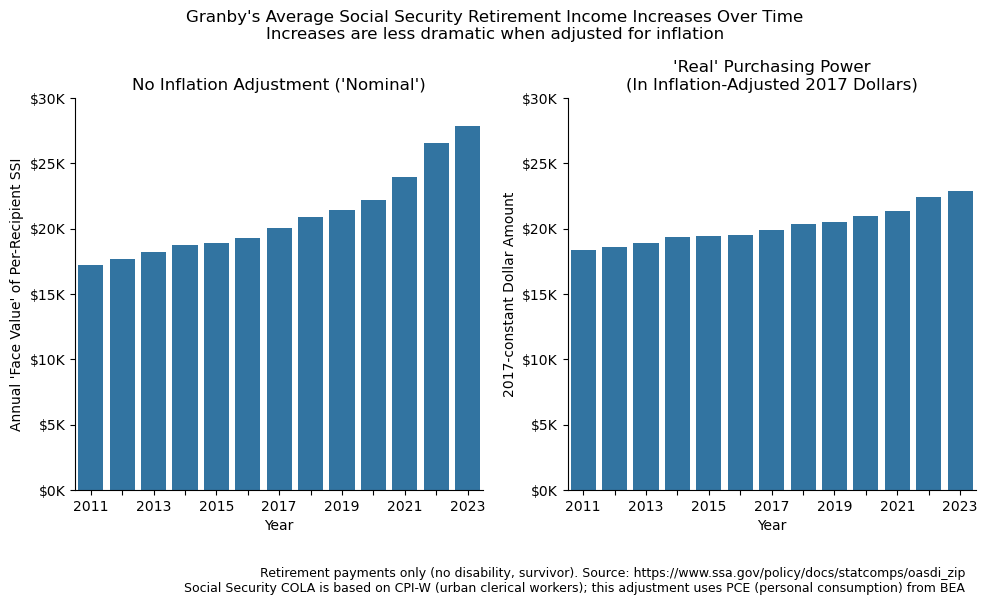

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(10,6))

line1 = "Granby's Average Social Security Retirement Income Increases Over Time\n"
line2 = "Increases are less dramatic when adjusted for inflation"
fig.suptitle(line1 + line2)

sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Annual SSI (Retired)',
                 ax = axs[0])
axs[0].set_title("No Inflation Adjustment ('Nominal')")
axs[0].set_ylabel("Annual 'Face Value' of Per-Recipient SSI")


sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Real Annual SSI (Retired)',
                 ax = axs[1])
axs[1].set_title("'Real' Purchasing Power\n(In Inflation-Adjusted 2017 Dollars)")
axs[1].set_ylabel("2017-constant Dollar Amount")

for ax in axs:
    ax.set_ylim(0,30000)
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0: # Check if the index is odd (for every other)
            label.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "Retirement payments only (no disability, survivor). Source: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip\n"
line2 = "Social Security COLA is based on CPI-W (urban clerical workers); this adjustment uses PCE (personal consumption) from BEA"
fig.text(.97, 0.01, line1 + line2, fontsize=9, ha='right')

sns.despine()
plt.savefig("./charts/social_security/ssi_real_retirement_ increase.png", dpi=200, metadata=png_metadata)

plt.show()

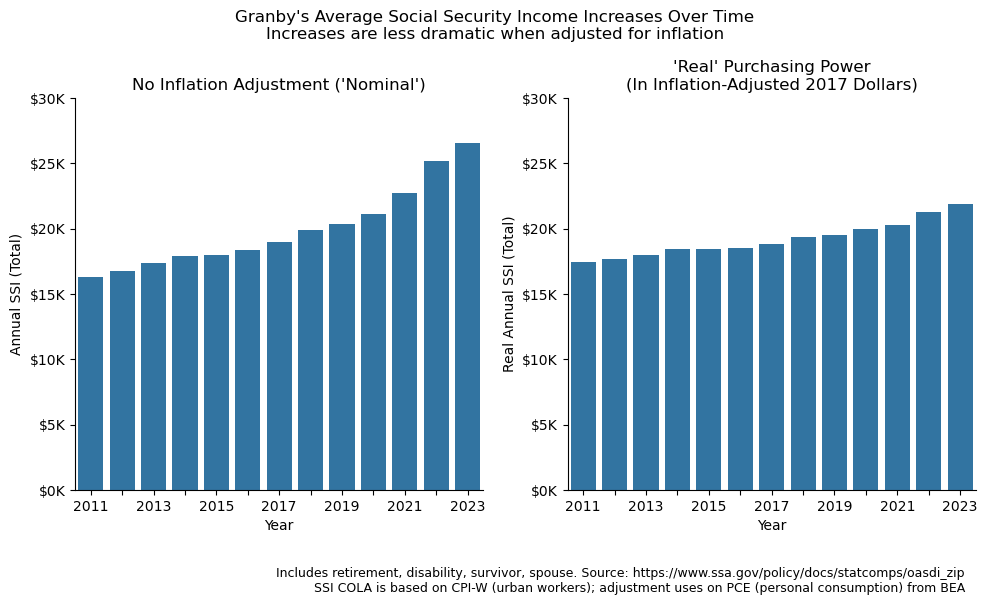

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(10,6))

line1 = "Granby's Average Social Security Income Increases Over Time\n"
line2 = "Increases are less dramatic when adjusted for inflation"
fig.suptitle(line1 + line2)

sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Annual SSI (Total)',
                 ax = axs[0])
axs[0].set_title("No Inflation Adjustment ('Nominal')")


sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Real Annual SSI (Total)',
                 ax = axs[1])
axs[1].set_title("'Real' Purchasing Power\n(In Inflation-Adjusted 2017 Dollars)")

for ax in axs:
    ax.set_ylim(0,30000)
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0: # Check if the index is odd (for every other)
            label.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "Includes retirement, disability, survivor, spouse. Source: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip\n"
line2 = "SSI COLA is based on CPI-W (urban workers); adjustment uses on PCE (personal consumption) from BEA"

fig.text(.97, 0.01, line1 + line2, fontsize=9, ha='right')
sns.despine()

plt.savefig("./charts/social_security/ssi_real_increase.png", dpi=200, metadata=png_metadata)

plt.show()

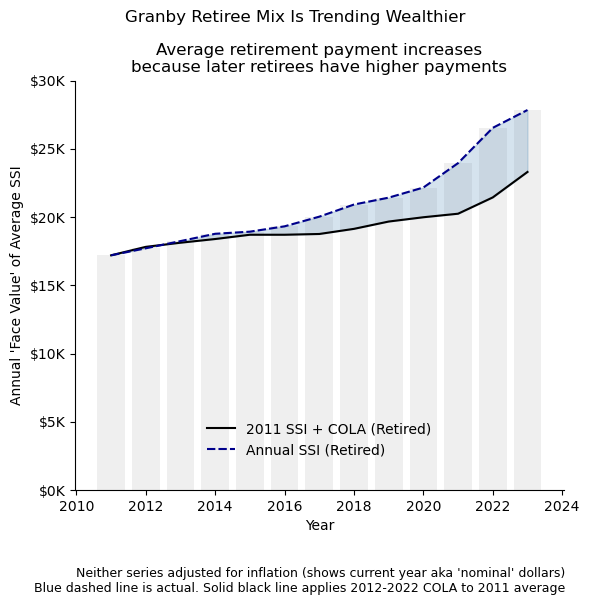

In [48]:
_df = town_ssi.query('Town == "Granby"').melt(id_vars=["Year"], var_name="Income",
                                              value_vars= ['2011 SSI + COLA (Retired)',
                                                           'Real 2011 SSI + COLA (Retired)',
                                                           'Real Annual SSI (Retired)',
                                                           'Real 2011 SSI w/o COLA (Retired)',
                                                           'Annual SSI (Retired)']
                                            )

fig, ax = plt.subplots(1, 1, figsize=(6,6),)
fig.suptitle("Granby Retiree Mix Is Trending Wealthier")

ax.bar(town_ssi.query('Town == "Granby"')['Year'], town_ssi.query('Town == "Granby"')['Annual SSI (Retired)'],
           color='lightgray', alpha=.35)

sns.lineplot(_df.query('~Income.str.startswith("Real")'), x='Year', y='value',
             hue='Income', palette=['black', 'darkblue'], 
             style='Income', 
              ax = ax)

ax.fill_between(town_ssi.query('Town == "Granby"').Year,
                    town_ssi.query('Town == "Granby"')['Annual SSI (Retired)'],
                    town_ssi.query('Town == "Granby"')['2011 SSI + COLA (Retired)'],color='steelblue', alpha=0.225)

sns.despine()
sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, .05), frameon=False, title='')
ax.set_title("Average retirement payment increases\nbecause later retirees have higher payments")
ax.set_ylabel("Annual 'Face Value' of Average SSI")
ax.set_ylim(0,30000)
ax.yaxis.set_major_formatter(dollar_k_formatter)


plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "Neither series adjusted for inflation (shows current year aka 'nominal' dollars)\n"
line2 = "Blue dashed line is actual. Solid black line applies 2012-2022 COLA to 2011 average"
fig.text(.95, .01, line1 + line2, fontsize=9, ha='right')

plt.savefig("./charts/social_security/ssi_mix_changes.png", dpi=200, metadata=png_metadata)

plt.show()

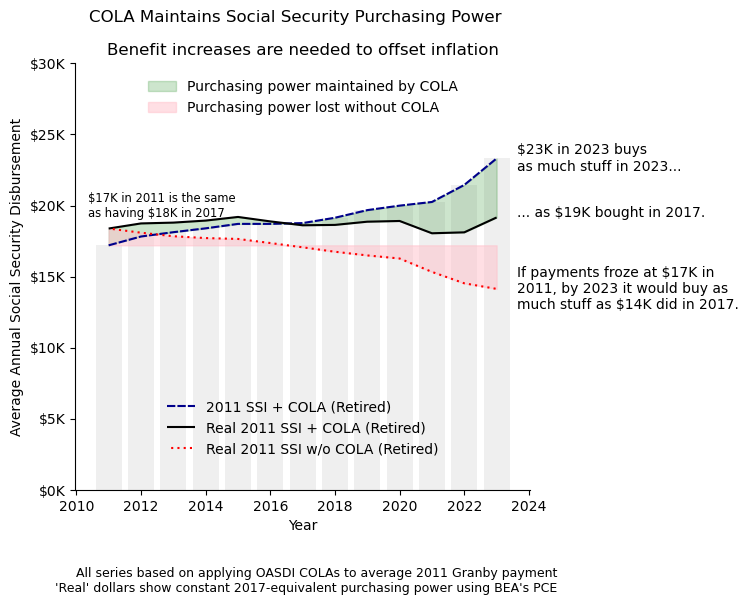

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(7.5,6),)

fig.suptitle("COLA Maintains Social Security Purchasing Power", x=.4)
ax.set_title("Benefit increases are needed to offset inflation")

_tssi = town_ssi.query('Town == "Granby"')
ax.bar(_tssi['Year'],
       _tssi['2011 SSI + COLA (Retired)'],
           color='lightgray', alpha=.35)

sns.lineplot(_df.query('Income.str.find("COLA") > 0'), x='Year', y='value',
             hue='Income', palette=[ 'darkblue', 'black', 'red'],
             style='Income',  dashes=[(4, 1), (1, 0), (0, 2, 1, 0)],
             ax = ax)

ax.add_artist(ax.legend(loc="lower center", bbox_to_anchor=(.5, .05), frameon=False, title=''))
#sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, .05), frameon=False, title='')
ax.set_ylabel("Value")

ul = ax.fill_between(_tssi.Year,
                    _tssi['2011 SSI + COLA (Retired)'],
                    _tssi['Real 2011 SSI + COLA (Retired)'],color='forestgreen',
                    alpha=0.225, label='Purchasing power maintained by COLA')

ll = ax.fill_between(_tssi.Year,
                    _tssi['Annual SSI 2011 (Retired)'],
                    _tssi['Real 2011 SSI w/o COLA (Retired)'],
                     color='pink', alpha=0.5,
                    label='Purchasing power lost without COLA'
                   )

_amt2011 = _tssi['Annual SSI 2011 (Retired)'].mean()
_ramt2011 = _tssi[_tssi.Year == _tssi.Year.min()]['Real 2011 SSI w/o COLA (Retired)'].item()
lina = "$17K in 2011 is the same\n"
linb = f"as having ${_ramt2011/1000:.0f}K in 2017"
ax.annotate(lina + linb, 
            (_tssi.Year.min(), _amt2011),
            xytext=(-15,18), textcoords='offset points', va='bottom', ha='left',
            fontsize='small')

_toploc = _tssi[_tssi.Year == _tssi.Year.max()]['2011 SSI + COLA (Retired)'].item()
ax.annotate(f"${_toploc/1000:.0f}K in {_tssi.Year.max()} buys\nas much stuff in {_tssi.Year.max()}...", 
            (_tssi.Year.max(), _toploc),
            xytext=(15,0), textcoords='offset points', va='center', ha='left')

_midloc = _tssi[_tssi.Year == _tssi.Year.max()]['Real 2011 SSI + COLA (Retired)'].item()
ax.annotate(f"... as ${_midloc/1000:.0f}K bought in 2017.",  
            (_tssi.Year.max(), _midloc), 
            xytext=(15,0), textcoords='offset points')

_botloc = _tssi[_tssi.Year == _tssi.Year.max()]['Real 2011 SSI w/o COLA (Retired)'].item()
_botstart = _tssi[_tssi.Year == _tssi.Year.min()]['2011 SSI + COLA (Retired)'].item()
line1 = f"If payments froze at ${_botstart/1000:,.0f}K in\n"
line2 = f"{_tssi.Year.min()}, by {_tssi.Year.max()} it would buy as\n"
line3 = f"much stuff as ${_botloc/1000:.0f}K did in 2017."
ax.annotate(line1 + line2 + line3, 
            (_tssi.Year.max(), _botloc), 
            xytext=(15,0), textcoords='offset points', va='center')

ax.legend(handles=[ul, ll],loc="upper center", bbox_to_anchor=(.5, .99), frameon=False, title='')

ax.set_ylim(0,30000)
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylabel('Average Annual Social Security Disbursement')


plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "All series based on applying OASDI COLAs to average 2011 Granby payment\n"
line2 = "'Real' dollars show constant 2017-equivalent purchasing power using BEA's PCE"
fig.text(.75, 0.01, line1 + line2, fontsize=9, ha='right')
sns.despine()

plt.savefig("./charts/social_security/ssi_inflation_effect.png", dpi=200, metadata=png_metadata)

plt.show()

### Spending inflation adjustment

In [50]:
gfi = fiscal_indicators.query('Town == "Granby"').copy().sort_values('Year')

# add price indices
gfi = gfi.merge(pce, how='left', on='Year')
gfi = gfi.merge(ipd, how='left', on='Year')
gfi['2013 PCE'] = gfi.query('Year == 2013')['PCE'].item()
gfi['2013 IPD'] = gfi.query('Year == 2013')['IPD'].item()
gfi['COLA PCE'] = gfi['PCE']/gfi['2013 PCE'].cumprod()
gfi['COLA IPD'] = gfi['IPD']/gfi['2013 IPD'].cumprod()

gfi['Spending Per Student'] = gfi['Education Expenditures'] / gfi['Average Daily Membership School Enrollment (State Education Dept)']
gfi['2013 Spending Per Student'] = gfi.query('Year == 2013')['Spending Per Student'].item()

# 75% of expenditures are payroll so deflate accordingly
gfi['Blended COLA'] = (.25*gfi['COLA IPD'] + .75*gfi['COLA PCE'])
gfi['2013 Spending Per Student + COLA'] = gfi['Blended COLA'] * gfi['2013 Spending Per Student']
gfi['Real 2013 Spending Per Student'] = gfi['2013 Spending Per Student'] / gfi['Blended COLA']
gfi['Real Spending Per Student'] = gfi['Spending Per Student'] / gfi['Blended COLA']
_vars = ['Spending Per Student', '2013 Spending Per Student + COLA',
     'Real Spending Per Student', 'Real 2013 Spending Per Student']
gfi[['Year'] + _vars + ['COLA PCE', 'COLA IPD']]\
   .style.format({x: "${:,.0f}" for x in _vars} | {x: "{:.2f}" for x in ['COLA PCE', 'COLA IPD']})

,Year,Spending Per Student,2013 Spending Per Student + COLA,Real Spending Per Student,Real 2013 Spending Per Student,COLA PCE,COLA IPD
0,2013,"$15,140","$15,140","$15,140","$15,140",1.00,1.00
1,2014,"$15,768","$15,845","$15,067","$14,467",1.04,1.05
2,2015,"$16,253","$16,444","$14,964","$13,940",1.09,1.08
3,2016,"$18,478","$17,293","$16,177","$13,255",1.15,1.13
4,2017,"$19,002","$18,314","$15,709","$12,516",1.21,1.21
5,2018,"$17,591","$19,429","$13,708","$11,798",1.28,1.30
6,2019,"$19,659","$20,442","$14,560","$11,214",1.35,1.36
7,2020,"$21,261","$21,577","$14,918","$10,624",1.42,1.45
8,2021,"$21,571","$23,879","$13,677","$9,600",1.56,1.63
9,2022,"$23,454","$26,195","$13,556","$8,751",1.71,1.80


In [51]:
_df = gfi.melt(id_vars=["Year"], var_name="Spending",
              value_vars= ['Spending Per Student', 'Real Spending Per Student', 'Real 2013 Spending Per Student']
            )

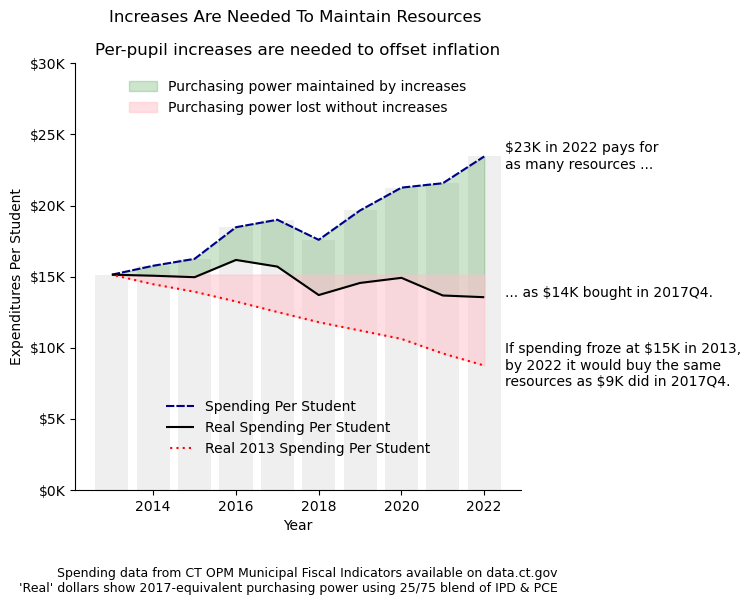

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(7.5,6),)

fig.suptitle("Increases Are Needed To Maintain Resources", x=.4)
ax.set_title("Per-pupil increases are needed to offset inflation")

ax.bar(gfi['Year'], 
       gfi['Spending Per Student'],
           color='lightgray', alpha=.35)

sns.lineplot(_df, x='Year', y='value',
             hue='Spending', palette=[ 'darkblue', 'black', 'red'],
             style='Spending',  dashes=[(4, 1), (1, 0), (0, 2, 1, 0)],
             ax = ax)

ax.add_artist(ax.legend(loc="lower center", bbox_to_anchor=(.5, .05), frameon=False, title=''))
#sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, .05), frameon=False, title='')
ax.set_ylabel("Value")

ul = ax.fill_between(gfi.Year,
                    gfi['Spending Per Student'],
                    gfi['Real Spending Per Student'],
                    color='forestgreen',
                    alpha=0.225, label='Purchasing power maintained by increases')

ll = ax.fill_between(gfi.Year,
                     gfi['2013 Spending Per Student'],
                     gfi['Real 2013 Spending Per Student'],
                     color='pink', alpha=0.5,
                     label='Purchasing power lost without increases'
                   )

_toploc = gfi[gfi.Year == gfi.Year.max()]['Spending Per Student'].item()
ax.annotate(f"${_toploc/1000:.0f}K in {gfi.Year.max()} pays for\nas many resources ...", 
            (gfi.Year.max(), _toploc),
            xytext=(15,0), textcoords='offset points', va='center', ha='left')

_midloc = gfi[gfi.Year == gfi.Year.max()]['Real Spending Per Student'].item()
ax.annotate(f"... as ${_midloc/1000:.0f}K bought in 2017Q4.",  
            (gfi.Year.max(), _midloc), 
            xytext=(15,0), textcoords='offset points')

_botloc = gfi[gfi.Year == gfi.Year.max()]['Real 2013 Spending Per Student'].item()
_botstart = gfi[gfi.Year == gfi.Year.min()]['2013 Spending Per Student'].item()
line1 = f"If spending froze at ${_botstart/1000:,.0f}K in {gfi.Year.min()},\n"
line2 = f"by {gfi.Year.max()} it would buy the same\n"
line3 = f"resources as ${_botloc/1000:.0f}K did in 2017Q4."
ax.annotate(line1 + line2 + line3, 
            (gfi.Year.max(), _botloc), 
            xytext=(15,0), textcoords='offset points', va='center')

ax.legend(handles=[ul, ll],
         loc="upper center", bbox_to_anchor=(.5, .99), frameon=False, title='')

ax.set_ylim(0,30000)
ax.set_ylabel('Expenditures Per Student')
ax.yaxis.set_major_formatter(dollar_k_formatter)

sns.despine()

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "Spending data from CT OPM Municipal Fiscal Indicators available on data.ct.gov\n"
line2 = "'Real' dollars show 2017-equivalent purchasing power using 25/75 blend of IPD & PCE"
fig.text(.75, 0.01, line1 + line2, fontsize=9, ha='right')

plt.savefig("./charts/social_security/school_inflation_effect.png", dpi=200, metadata=png_metadata)

plt.show()

In [53]:
gfi.columns

Index(['Town', 'Tax Code', 'Municipality FIPS', 'Municipality FIPS GEOID',
       'Fiscal Year End', 'Population (State Dept of Public Health)',
       'Average Daily Membership School Enrollment (State Education Dept)',
       'Bond Rating as of July 1 (Moody's)', 'Unemployment Annual Average',
       'Equalized Net Grand List', 'Equalized Mill Rate', 'Net Grand List',
       'Mill Rate Real Estate Personal Property', 'Mill Rate Motor Vehicle',
       'Current Year Adjusted Tax Levy', 'Current Year Tax Collection',
       'Total Taxes Collected as a af Total Outstanding',
       'Property Tax Revenues', 'Intergovernmental Revenues', 'Total Revenues',
       'Total Transfers in from Other Funds',
       'Total Revenues and Other Financing Sources', 'Education Expenditures',
       'Operating Expenditures', 'Total Expenditures',
       'Total Transfers Out to Other Funds',
       'Total Expenditures and Other Financing Uses',
       'Net Change in Fund Balance', 'Nonspendable', 'Restric

### IRS Income
Also reported by zip. Needs to be summed to town.

In [54]:
irs_cols = [
 'ZIP code',
 'Year',
 'Size of adjusted gross income',
 'Number of individuals',
 'Number of returns',
 'Number of single returns',
 'Number of joint returns',
 'Number of head of household returns',
 'Number of exemptions',
 'Number of dependents',
 'Number of elderly returns',
 'Adjusted gross income (AGI)',
 'Total income Number of returns',
 'Total income Amount',
 'Taxable income Number of returns',
 'Taxable income Amount',
 'Income tax Number of returns',
 'Income tax Amount',
 'Total tax liability Amount',
 'Total additional Medicare tax Number of returns',
 'Total additional Medicare tax Amount',
 'Social Security benefits in AGI Number of returns',
 'Social Security benefits in AGI Amount',
 'Taxable Social Security benefits Number of returns',
 'Taxable Social Security benefits Amount',
 'Taxable individual retirement arrangements distributions Number of returns',
 'Taxable individual retirement arrangements distributions Amount',
 'Taxable individual retirement arrangement distributions Amount',
 'Taxable individual retirement arrangement distributions Number of returns',
 'Pensions and annuities in AGI Number of returns',
 'Pensions and annuities in AGI Amount',
 'IRA payments Amount',
 'IRA payments Number of returns',
 'Taxable IRA, pensions and annuities Number of returns',
 'Taxable IRA, pensions and annuities Amount',
 'Taxable pensions and annuities Amount',
 'Taxable pensions and annuities Number of returns',
 ]

In [55]:
# read cleaned workbooks
ds = []
for year in range(2012, 2023):
    df = pd.read_excel(irs_file, sheet_name=str(year))
    df['Year'] = year
    ds.append(df)

In [56]:
# Fix column names
# Except Not sure what '0 Amount' refers to
for df in ds:
    cols = [" ".join(col.replace("\n", " ").split()) for col in df.columns.to_list()]
    cols = [" ".join(col.replace("\\", " ").split()) for col in df.columns.to_list()]
    cols = [" ".join(col.replace("0 Amount of AGI", "0 Amount").split()) for col in df.columns.to_list()]
    cols = [" ".join(re.sub(r'\[\d+\]', '', col).split()) for col in cols]
    df.columns = cols

In [57]:
# combine years
incomes = pd.concat(ds).copy()
del ds

incomes['Size of adjusted gross income'] = incomes['Size of adjusted gross income'].fillna("Total")

# get all columns before Town, District
income_cols = list(incomes.columns)

# keep only some
incomes.drop(columns=[c for c in income_cols if c not in irs_cols], inplace=True)
incomes.shape

(20307, 37)

#### Components of Retirement Income Index do not overlap

In [58]:
# show no overlap when summing
incomes[(incomes['ZIP code'] == 6035) & (incomes['Size of adjusted gross income'] == 'Total')]\
    [['Year', 'Pensions and annuities in AGI Amount', 
      'Taxable pensions and annuities Amount', 
      'Taxable IRA, pensions and annuities Amount', 
      'Taxable individual retirement arrangement distributions Amount',
      'Taxable individual retirement arrangements distributions Amount',
   'Social Security benefits in AGI Amount', 'Taxable Social Security benefits Amount' ]]

,Year,Pensions and annuities in AGI Amount,Taxable pensions and annuities Amount,"Taxable IRA, pensions and annuities Amount",Taxable individual retirement arrangement distributions Amount,Taxable individual retirement arrangements distributions Amount,Social Security benefits in AGI Amount,Taxable Social Security benefits Amount
119,2012,24034.0,NaN,NaN,9680.0,NaN,10024.0,NaN
119,2013,25345.0,NaN,NaN,9837.0,NaN,NaN,10714.0
119,2014,27913.0,NaN,NaN,11635.0,NaN,NaN,11883.0
119,2015,27057.0,NaN,NaN,10994.0,NaN,NaN,11671.0
119,2016,27962.0,NaN,NaN,11863.0,NaN,NaN,12042.0
119,2017,28716.0,NaN,NaN,13877.0,NaN,NaN,13290.0
119,2018,NaN,NaN,45035.0,NaN,NaN,NaN,14636.0
119,2019,NaN,31886.0,NaN,NaN,15049.0,NaN,15355.0
119,2020,NaN,32142.0,NaN,NaN,12515.0,NaN,16353.0
119,2021,NaN,34025.0,NaN,NaN,18844.0,NaN,18747.0


In [59]:
# compare number of returns -> 
incomes[(incomes['ZIP code'] == 6035) & (incomes['Size of adjusted gross income'] == 'Total')]\
    [['Year', 'Number of elderly returns', 'Pensions and annuities in AGI Number of returns', 
      'Taxable pensions and annuities Number of returns', 
      'Taxable IRA, pensions and annuities Number of returns', 
      'Taxable individual retirement arrangement distributions Number of returns',
      'Taxable individual retirement arrangements distributions Number of returns',
   'Social Security benefits in AGI Number of returns', 'Taxable Social Security benefits Number of returns' ]]

,Year,Number of elderly returns,Pensions and annuities in AGI Number of returns,Taxable pensions and annuities Number of returns,"Taxable IRA, pensions and annuities Number of returns",Taxable individual retirement arrangement distributions Number of returns,Taxable individual retirement arrangements distributions Number of returns,Social Security benefits in AGI Number of returns,Taxable Social Security benefits Number of returns
119,2012,NaN,950.0,NaN,NaN,580.0,NaN,650.0,NaN
119,2013,NaN,950.0,NaN,NaN,600.0,NaN,NaN,660.0
119,2014,NaN,980.0,NaN,NaN,600.0,NaN,NaN,710.0
119,2015,1150.0,970.0,NaN,NaN,600.0,NaN,NaN,710.0
119,2016,1160.0,950.0,NaN,NaN,620.0,NaN,NaN,730.0
119,2017,1210.0,990.0,NaN,NaN,680.0,NaN,NaN,760.0
119,2018,1300.0,NaN,NaN,1240.0,NaN,NaN,NaN,790.0
119,2019,1310.0,NaN,1020.0,NaN,NaN,730.0,NaN,820.0
119,2020,1380.0,NaN,1070.0,NaN,NaN,610.0,NaN,870.0
119,2021,1400.0,NaN,1040.0,NaN,NaN,720.0,NaN,890.0


In [60]:
incomes['Taxable Retirement Income'] = \
     incomes[['Pensions and annuities in AGI Amount', 
              'Taxable pensions and annuities Amount', 
              'Taxable IRA, pensions and annuities Amount', 
              'Taxable individual retirement arrangement distributions Amount',
              'Taxable individual retirement arrangements distributions Amount',
               'Social Security benefits in AGI Amount', 'Taxable Social Security benefits Amount']].fillna(0).sum(axis=1)

#### Match zip to town

In [61]:
# map zip to town
s = incomes.merge(zips, how='left', on='ZIP code')
s = s.merge(po_towns.rename(columns={'Town': 'PO_Town'}), how='left', on='ZIP code')

# check missing (uses placeholder name)
# only overall totals missing
s['Town'] = s['Town'].fillna('PO_Town')
s[(s['Town'] == 'PO_Town')]['ZIP code'].value_counts()

ZIP code
0        77
99999    77
Name: count, dtype: int64

In [62]:
# looks okay, rename
incomes = s.copy()
del s

#### Sum zipcodes to town

In [63]:
# select cols for aggregation
aggcols = [col for col in incomes.select_dtypes(exclude=[object])]
aggcols = [col for col in aggcols if col not in ['Year', 'Town', 'District', 'ZIP code',
                                                         'Size of adjusted gross income']]

# roll to town level
town_incomes = pd.DataFrame(incomes.groupby(['Town', 'Year', 'Size of adjusted gross income'])[aggcols].agg('sum'))\
               .reset_index(drop=False)

**Check missing towns in IRS data**  
If missing, they won't get the fiscal indicators data and will need imputation. B/c Old Lyme and Lyme are in the same Regional School, we can use Lyme for Old Lyme to aggregate the fiscal indicators.

In [64]:
[c for c in cttaxes.Town.unique() if not c in incomes.Town.unique()]

['Lisbon', 'Old Lyme', 'Union']

In [65]:
[c for c in fiscal_indicators.Town.unique() if not c in incomes.Town.unique()]

['Groton (City)', 'Lisbon', 'Old Lyme', 'Union']

In [66]:
[c for c in eqlist.Town.unique() if not c in incomes.Town.unique()]

['Lisbon', 'Old Lyme', 'Union', 'Total', nan]

In [67]:
# union sends high school to these or tolland or storrs
incomes[incomes['ZIP code'].isin([6076, 6242, 6281])]['Town'].unique()

array(['Stafford', 'Eastford', 'Woodstock'], dtype=object)

In [68]:
# lisbon -- ignore unless using group 13
incomes[incomes['ZIP code'].isin([6351, 6380, 6330])]['Town'].unique()

array(['Sprague', 'Griswold', 'Norwich'], dtype=object)

#### Add Social Security Income, Fiscal Indicators, PCE at town

In [69]:
# combine Lyme & Old Lyme
nonsummable = ["Bond Rating as of July 1 (Moody's)", 'Tax Code', 'Unemployment Annual Average', 'Equalized Mill Rate',
              'Municipality FIPS' , 'Municipality FIPS GEOID', 'Mill Rate Real Estate Personal Property',
              'Mill Rate Motor Vehicle', 'Total Taxes Collected as a af Total Outstanding', 'Fiscal Year End']
ns = [c for c in fiscal_indicators if c in nonsummable]

_fiscal_indicators = fiscal_indicators.drop(columns=ns).copy()
_fiscal_indicators['Town'] = _fiscal_indicators['Town'].where((_fiscal_indicators['Town'] != 'Old Lyme'), 'Lyme')

summable = [c for c in _fiscal_indicators if c not in ['Town', 'Year', 'Size of adjusted gross income']]
_fiscal_indicators = _fiscal_indicators.groupby(['Town', 'Year', 'Size of adjusted gross income'])[summable].sum().reset_index(drop=False)

_cttaxes = cttaxes.copy()
_cttaxes['Town'] = _cttaxes['Town'].where((_cttaxes['Town'] != 'Old Lyme'), 'Lyme')
_cttaxes = _cttaxes.groupby(['Town', 'Year'])['CT Income Tax'].sum().reset_index(drop=False)

_eqlist = eqlist[['Year', 'Town', 'CIP Net', 'Total Net Assessment', 
                  'Residential Net', 'Residential Equalized', 'Non-CIP Equalized']].copy()
_eqlist['Town'] = _eqlist['Town'].where((_eqlist['Town'] != 'Old Lyme'), 'Lyme')
_eqlist = _eqlist.groupby(['Town', 'Year'])[['CIP Net', 'Total Net Assessment', 'Non-CIP Equalized',
                                            'Residential Net', 'Residential Equalized']].sum().reset_index(drop=False)

# add town data to incomes
town_incomes = town_incomes.merge(town_ssi[['Annual SSI (Total)', 'Annual SSI (Retired)',
                                            'Size of adjusted gross income',
                                            'Recipients', 'Recipients 65+', 'Year', 'Town']],
                                 on=['Year', 'Town', 'Size of adjusted gross income'], how='left')\
                           .merge(_fiscal_indicators, on=['Year', 'Town', 'Size of adjusted gross income'], how='left')\
                           .merge(_cttaxes, on=['Year', 'Town'], how='left')\
                           .merge(_eqlist, on=['Year', 'Town'], how='left')\
                           .merge(pce, on='Year', how='left')\
                           .query('Year >= 2013')

town_incomes['Fiscal Year End'] = town_incomes['Year'] + 1

In [70]:
town_incomes.columns

Index(['Town', 'Year', 'Size of adjusted gross income', 'Number of returns',
       'Number of single returns', 'Number of joint returns',
       'Number of head of household returns', 'Number of exemptions',
       'Number of dependents', 'Number of elderly returns',
       'Adjusted gross income (AGI)',
       'Taxable individual retirement arrangement distributions Number of returns',
       'Taxable individual retirement arrangement distributions Amount',
       'Pensions and annuities in AGI Number of returns',
       'Pensions and annuities in AGI Amount',
       'Social Security benefits in AGI Number of returns',
       'Social Security benefits in AGI Amount',
       'Taxable income Number of returns', 'Taxable income Amount',
       'Income tax Number of returns', 'Income tax Amount',
       'Total tax liability Amount', 'Total income Number of returns',
       'Total income Amount',
       'Taxable Social Security benefits Number of returns',
       'Taxable Social Security 

#### Sum towns to school districts
Mostly needed for the regional schools

In [71]:
# map towns to district
town_incomes['District'] = town_incomes['Town'].map(regional_map)
town_incomes['District'] = town_incomes['District'].where(town_incomes['District'].notna(), town_incomes['Town'] + " School District")
town_incomes['District'] = town_incomes['District'].str.strip()

# find numeric columns to agg
aggcols = [col for col in town_incomes.select_dtypes(exclude=[object])]
aggcols = [col for col in aggcols if col not in ['Year', 'Town', 'District', 'ZIP code', 'Fiscal Year End',
                                                         'Size of adjusted gross income', 'PCE']]
# now aggregate to district
district_incomes = pd.DataFrame(town_incomes.drop(columns=['Town'])\
                   .groupby(['District', 'Year', 'Fiscal Year End', 'Size of adjusted gross income'])[aggcols].agg('sum'))\
                   .reset_index(drop=False)

district_incomes = district_incomes.merge(school_types, how='left',  on='District')\
                                   .merge(pce, on='Year', how='left')

In [72]:
# check for missing towns
town_incomes[town_incomes['Size of adjusted gross income'].isna()].head(10)

,Town,Year,Size of adjusted gross income,Number of returns,Number of single returns,Number of joint returns,Number of head of household returns,Number of exemptions,Number of dependents,Number of elderly returns,...,Annual Debt Service,CT Income Tax,CIP Net,Total Net Assessment,Non-CIP Equalized,Residential Net,Residential Equalized,PCE,Fiscal Year End,District


In [73]:
# check for missing towns
district_incomes[district_incomes['Size of adjusted gross income'].isna()].head(10)

,District,Year,Fiscal Year End,Size of adjusted gross income,Number of returns,Number of single returns,Number of joint returns,Number of head of household returns,Number of exemptions,Number of dependents,...,% w/Bachelors+,% Management,% Single Parent,% Non-English,% SNAP,School Enrollment,% HH w/Children,% w/Broadband,% Age 65+,PCE


In [74]:
# part of Yantic & Lakeside (Morris) missing years
s = pd.DataFrame(incomes['ZIP code'].value_counts())
s[s['count'] != 77]

,count
ZIP code,
6389,42
6758,14


#### Sortable income bands

In [75]:
income_band = list(incomes['Size of adjusted gross income'].value_counts().index)
income_band = [b.replace('$', '\$') for b in income_band]
income_band

['Total',
 '\\$1 under \\$25,000',
 '\\$25,000 under \\$50,000',
 '\\$50,000 under \\$75,000',
 '\\$75,000 under \\$100,000',
 '\\$100,000 under \\$200,000',
 '\\$200,000 or more']

In [76]:
town_incomes['Income Band'] = pd.Categorical(town_incomes['Size of adjusted gross income'].str.replace('$', '\$'),
                                                               categories=income_band, ordered=True)

In [77]:
district_incomes['Income Band'] = pd.Categorical(district_incomes['Size of adjusted gross income'].str.replace('$', '\$'),
                                                               categories=income_band, ordered=True)

## Uniform Chart Of Accounts

### Recent Uniform Chart

In [78]:
# 'Uniform_Chart_of_Accounts_Municipal_Spending_Data.csv'
# 'Uniform_Chart_of_Accounts_Municipal_Spending_Data_20251123.csv'
accounts = pd.read_csv(path.join(benchmark_dir, 'fiscal_indicators',
                                 'Municipal_Fiscal_Indicators__Uniform_Chart_of_Accounts_2020-2023_20260326.csv'))

accounts['Town'] = accounts['Entity Name'].str.title()
accounts['Salaries Wages'] = accounts['Salaries Wages'].str.replace("$", "").str.replace(",","").astype('float')
accounts['Employee Benefits'] = accounts['Employee Benefits'].str.replace("$", "").str.replace(",","").astype('float')
accounts['Other'] = accounts['Other'].str.replace("$", "").str.replace(",","").astype('float')
accounts['Total'] = accounts['Total'].str.replace("$", "").str.replace(",","").astype('float')

In [79]:
# Relative size of Department Totals
_annl_tots = accounts[accounts['Department Description'] == 'Total Expenditures'].groupby(['Town', 'Year'])[['Salaries Wages', 'Employee Benefits', 'Other', 'Total']].sum().reset_index(drop=False)
_rename = {c: 'Total Town ' + c for c in ['Salaries Wages', 'Employee Benefits', 'Other', 'Total']}
_annl_tots.rename(columns=_rename, inplace=True)
accounts = accounts.merge(_annl_tots, on=['Town', 'Year'], how='left').drop(columns=['Tax Code', 'Municipality FIPS', 'Municipality FIPS GEOID', 'Function Code', 'Department Code'])

for col in ['Salaries Wages', 'Employee Benefits', 'Other', 'Total']:
    accounts[f"Share of {col}"] = accounts[col] / accounts[f"Total Town {col}"]

In [80]:
accounts[accounts['Town'] == 'Granby']

,Year,Entity Name,Function Description,Department Description,Salaries Wages,Employee Benefits,Other,Total,Town,Total Town Salaries Wages,Total Town Employee Benefits,Total Town Other,Total Town Total,Share of Salaries Wages,Share of Employee Benefits,Share of Other,Share of Total
988,2023,GRANBY,General Government,General Government,1226705.0,2859355.0,929218.0,5015278.0,Granby,25399765.0,8538200.0,19609276.0,53547241.0,0.048296,0.334890,0.047387,0.093661
989,2023,GRANBY,Public Safety,Fire,29614.0,0.0,339487.0,369101.0,Granby,25399765.0,8538200.0,19609276.0,53547241.0,0.001166,0.000000,0.017313,0.006893
990,2023,GRANBY,Public Safety,Other Public Safety,165983.0,0.0,181308.0,347291.0,Granby,25399765.0,8538200.0,19609276.0,53547241.0,0.006535,0.000000,0.009246,0.006486
991,2023,GRANBY,Public Safety,Police,2132189.0,0.0,119581.0,2251770.0,Granby,25399765.0,8538200.0,19609276.0,53547241.0,0.083945,0.000000,0.006098,0.042052
992,2023,GRANBY,Public Works,Highways/Streets,0.0,0.0,0.0,0.0,Granby,25399765.0,8538200.0,19609276.0,53547241.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16264,2020,GRANBY,Debt Service Total,Debt Service Total,NaN,NaN,2767355.0,2767355.0,Granby,23725053.0,7353609.0,17031577.0,48110239.0,NaN,NaN,0.162484,0.057521
16265,2020,GRANBY,Debt Service,Debt Service,NaN,NaN,2767355.0,2767355.0,Granby,23725053.0,7353609.0,17031577.0,48110239.0,NaN,NaN,0.162484,0.057521
16266,2020,GRANBY,Education Total,Education Total,18426284.0,4881704.0,11266796.0,34574784.0,Granby,23725053.0,7353609.0,17031577.0,48110239.0,0.776659,0.663851,0.661524,0.718657
16267,2020,GRANBY,Education,Regional School District,NaN,NaN,0.0,0.0,Granby,23725053.0,7353609.0,17031577.0,48110239.0,NaN,NaN,0.000000,0.000000


In [81]:
# use Department Description to select appropriate row; agged to one row per town per year
# seems like there are entries for 
pd.DataFrame(accounts.groupby(['Function Description', 'Department Description'])[['Town', 'Year']].nunique())

Town  Year
Function Description         Department Description                  
Capital Outlay               Capital Outlay                 168     4
Capital Outlay Total         Capital Outlay Total           168     4
Culture and Recreation       Libraries                      168     4
                             Other Culture/Recreation       168     4
                             Recreation                     168     4
Culture and Recreation Total Culture and Recreation Total   168     4
Debt Service                 Debt Service                   168     4
Debt Service Total           Debt Service Total             168     4
Education                    Board of Education             168     4
                             Regional School District       168     4
Education Total              Education Total                168     4
General Government           General Government             168     4
General Government Total     General Government Total       168     4
Health and Welfare           Other Health & Welfare         168     4
                             Public Health Admin            168     4
                             Social Services                168     4
Health and Welfare Total     Health and Welfare Total       168     4
Other                        Other                          168     4
Other Total                  Other Total                    168     4
Public Safety                Fire                           168     4
                             Other Public Safety            168     4
                             Police                         168     4
Public Safety Total          Public Safety Total            168     4
Public Works                 Highways/Streets               168     4
                             Other Public Works             168     4
                             Sewer                          168     4
                             Waste Management               168     4
Public Works Total           Public Works Total             168     4
Total Expenditures           Total Expenditures             168     4

In [82]:
# granby has 29 ent
uc = pd.DataFrame(accounts.groupby(['Town', 'Year'])['Total'].count())
uc.reset_index(drop=False, inplace=True)
uc[uc['Town'] == 'Granby']

,Town,Year,Total
195,Granby,2020,29
196,Granby,2021,29
197,Granby,2022,29
198,Granby,2023,29


In [83]:
# Every town has the same department description
pd.DataFrame(accounts.groupby(['Town', 'Year'])[['Department Description']].nunique())['Department Description'].value_counts()

Department Description
29    608
Name: count, dtype: int64

In [84]:
# Every town has the same department description
pd.DataFrame(accounts.groupby(['Year'])['Town'].nunique())

,Town
Year,
2020,144
2021,144
2022,160
2023,160


#### Map to school districts

In [85]:
# add miles of road
accounts = accounts.merge(town_roads, on='Town', how='left')\
                   .merge(fiscal_indicators[['Town', 'Fiscal Year End', 'Population (State Dept of Public Health)', 'Equalized Net Grand List']]\
                                            .rename(columns={'Fiscal Year End': 'Year'}),
                          on=['Town', 'Year'], how='left')\
                   .rename(columns={'Population (State Dept of Public Health)': 'Population', 'Equalized Net Grand List': 'Net Equalized Grand List'})

# add population

# map towns to district
accounts['District'] = accounts['Town'].map(regional_map)
accounts['District'] = accounts['District'].where(accounts['District'].notna(), accounts['Town'] + " School District")
accounts['District'] = accounts['District'].str.strip()


# roll to district level
aggcols = ['Salaries Wages', 'Employee Benefits', 'Other', 'Total']
roadcols = ['Town Area', 'State Roads', 'Town Roads', 'Population', 'Net Equalized Grand List']
ttlcols = ['Total Town ' + c for c in aggcols]
district_accounts = pd.DataFrame(accounts.groupby(['District', 'Year', 'Function Description', 'Department Description'])\
                                 [aggcols + ttlcols + roadcols].sum()).reset_index(drop=False)

for col in ['Salaries Wages', 'Employee Benefits', 'Other', 'Total']:
    district_accounts[f"Share of {col}"] = district_accounts[col] / district_accounts[f"Total Town {col}"]
   

## Save Data

In [86]:
town_incomes.to_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_incomes.parquet')
district_incomes.to_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_incomes.parquet')
district_accounts.to_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_chart_of_accounts.parquet')
accounts.to_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_chart_of_accounts.parquet')

### Municipal Spending Data
Structure of data is different in 2014-2019, plus Granby only reports 2014 and 2019.

In [87]:
spending = pd.read_csv(path.join(benchmark_dir, 'fiscal_indicators', 'Uniform_Chart_of_Accounts_Municipal_Spending_Data.csv'),
                      low_memory=False)

local_vars = [c for c in spending.columns if c.startswith('Local')]
spending.drop(columns=local_vars, inplace=True)
uniform_vars = [c.replace('Uniform','') for c in spending.columns]
spending.columns=uniform_vars
spending.head(10)

,FiscalYear,Municipality,Account,Fund,Function,Department,Object,ProjectName,Debit,Credit
0,2014,Ansonia,1005-00-0000-00000-20000-000,Town General Fund,Undefined Function,Undefined Department,Liability,Undefined Project,NaN,0.0
1,2014,Ansonia,1005-00-0000-00000-43999-000,Town General Fund,Undefined Function,Undefined Department,Other Grants,Undefined Project,NaN,0.0
2,2014,Ansonia,1005-42-4201-00000-50000-000,Town General Fund,Public Safety,Police,Expenditure,Undefined Project,0.00,NaN
3,2014,Ansonia,1005-41-4101-00000-50000-000,Town General Fund,General Government,Legislative,Expenditure,Undefined Project,0.00,NaN
4,2014,Ansonia,1005-42-4203-00000-50000-000,Town General Fund,Public Safety,Fire,Expenditure,Undefined Project,19939.46,NaN
5,2014,Ansonia,1005-00-0000-00000-43999-000,Town General Fund,Undefined Function,Undefined Department,Other Grants,Undefined Project,NaN,-6203.0
6,2014,Ansonia,6001-00-0000-00000-20000-000,Wastewater,Undefined Function,Undefined Department,Liability,Undefined Project,NaN,-1548038.0
7,2014,Ansonia,1005-42-4299-00000-50000-000,Town General Fund,Public Safety,Other Public Safety,Expenditure,Undefined Project,1100.00,NaN
8,2014,Ansonia,1005-41-4199-00000-50000-000,Town General Fund,General Government,Other General Government,Expenditure,Undefined Project,850.00,NaN
9,2014,Ansonia,1005-41-4107-00000-50000-000,Town General Fund,General Government,Executive,Expenditure,Undefined Project,0.00,NaN


In [88]:
spending[spending['Municipality'] == 'Granby'].FiscalYear.value_counts()

FiscalYear
2014    763
2019    760
Name: count, dtype: int64

In [89]:
del spending